# Purchase Propensity Modeling

## Прогнозирование вероятности покупки пользователя на основе его первой сессии

---

## Описание проекта

В проекте анализируется поведение пользователей интернет-магазина и строится модель,
предсказывающая вероятность совершения покупки в течение 7 дней после первой сессии.

Модель использует только информацию, доступную на момент завершения первой сессии пользователя.

Основная задача:

> По поведению пользователя в первой сессии определить вероятность того,
> что он совершит покупку в течение следующих 7 дней.

Полученный прогноз может использоваться для:

- ранжирования пользователей по вероятности покупки;
- приоритизации маркетинговых активностей;
- персонализации рекомендаций;
- выбора пользователей для дальнейших маркетинговых экспериментов.

# 1. Постановка задачи

## Бизнес-проблема

Не все пользователи интернет-магазина одинаково склонны к совершению покупки.

Одни пользователи активно просматривают товары, добавляют их в корзину
и взаимодействуют с большим количеством продуктов.

Другие пользователи ограничиваются несколькими просмотрами и покидают сайт.

Бизнесу необходимо понимать, какие пользователи имеют более высокую вероятность
совершить покупку в ближайшие 7 дней.

## Цель проекта

Построить модель, которая по поведению пользователя во время первой сессии
оценивает:

$$
P(\text{purchase within 7 days} \mid \text{first session behavior})
$$

## Prediction Point

Момент принятия решения моделью:

> окончание первой сессии пользователя.

Все признаки должны быть рассчитаны только на основе информации,
доступной до этого момента.

## Target

Целевая переменная:

- `1` — пользователь совершил покупку в течение следующих 7 дней;
- `0` — пользователь не совершил покупку в течение следующих 7 дней.

Пользователи, совершившие покупку уже во время первой сессии,
исключаются из моделирования.

# 2. Импорт библиотек и настройка окружения

В этом разделе подключаются библиотеки для:

- обработки данных;
- визуализации;
- построения моделей;
- оценки качества;
- сохранения обученной модели.

In [1]:
import zipfile
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib


warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
HORIZON_DAYS = 7

# 3. Загрузка данных

Датасет содержит события пользователей интернет-магазина.

Каждая строка представляет отдельное пользовательское событие,
например:

- просмотр товара (`view`);
- добавление товара в корзину (`cart`);
- покупка (`purchase`).

**Источник данных:** [eCommerce events history in electronics store (Kaggle)](https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-electronics-store).

Чтобы запустить ноутбук локально:

1. Скачайте `events.csv` (или архив с ним) с Kaggle.
2. Положите файл в `data/` в корне проекта — либо укажите свой путь через переменную окружения `DATA_DIR`.

Данные не включены в репозиторий из-за размера (см. `.gitignore`).


In [ ]:
import os

DATA_DIR = Path(os.getenv('DATA_DIR', 'data'))
RAW_ZIP = DATA_DIR / 'archive.zip'
EXTRACT_DIR = DATA_DIR / 'extracted'

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

events_csv = EXTRACT_DIR / 'events.csv'
events_csv_flat = DATA_DIR / 'events.csv'  # на случай, если CSV лежит без архива

if events_csv_flat.exists():
    events_csv = events_csv_flat
elif not events_csv.exists():
    if RAW_ZIP.exists():
        with zipfile.ZipFile(RAW_ZIP, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
    else:
        raise FileNotFoundError(
            'Не найден датасет.\n'
            'Скачайте events.csv с Kaggle:\n'
            'https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-electronics-store\n'
            f'и положите его в {DATA_DIR}/ (или задайте свой путь через переменную окружения DATA_DIR).'
        )

df = pd.read_csv(events_csv)

print(f'Dataset shape: {df.shape}')
df.head()

# 4. Первичный анализ данных


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [4]:
df.describe(
    include='all'
).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_time,885129,845041,2021-02-04 21:48:32 UTC,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,885129,3,view,793748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,885129.000,NaN,NaN,NaN,1906620.536,1458708.099,102.000,698803.000,1452883.000,3721194.000,4183880.000
category_id,885129.000,NaN,NaN,NaN,2144422967987037184.000,616510516083801.250,2144415921001725952.000,2144415922528452608.000,2144415925011480832.000,2144415927519674624.000,2227847332769039360.000
category_code,648910,107,computers.components.videocards,116717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,672765,999,asus,27706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,885129.000,NaN,NaN,NaN,146.329,296.808,0.220,26.460,65.710,190.490,64771.060
user_id,885129.000,NaN,NaN,NaN,1515915625558965504.000,37472865.571,1515915625353227008.000,1515915625533004288.000,1515915625554085376.000,1515915625594517504.000,1515915625611024128.000
user_session,884964,490398,nFlhu5QzOd,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(
    'Количество событий:',
    len(df)
)

print(
    'Количество уникальных пользователей:',
    df['user_id'].nunique()
)

print(
    'Количество уникальных сессий:',
    df['user_session'].nunique()
)

Количество событий: 885129
Количество уникальных пользователей: 407283
Количество уникальных сессий: 490398


# 5. Подготовка типов данных


In [6]:
df['event_time'] = pd.to_datetime(
    df['event_time'],
    errors='coerce'
)

df['price'] = pd.to_numeric(
    df['price'],
    errors='coerce'
)

print(
    'Пропуски event_time:',
    df['event_time'].isna().sum()
)

print(
    'Пропуски price:',
    df['price'].isna().sum()
)


Пропуски event_time: 0
Пропуски price: 0


In [7]:
df = df.dropna(
    subset=[
        'event_time',
        'user_id',
        'user_session'
    ]
).copy()

# 6. Проверка дубликатов


In [8]:
duplicate_count = df.duplicated().sum()

print(
    f'Количество полных дубликатов: {duplicate_count}'
)
df = df.drop_duplicates().copy()

Количество полных дубликатов: 652


# 7. EDA

## Распределение типов событий


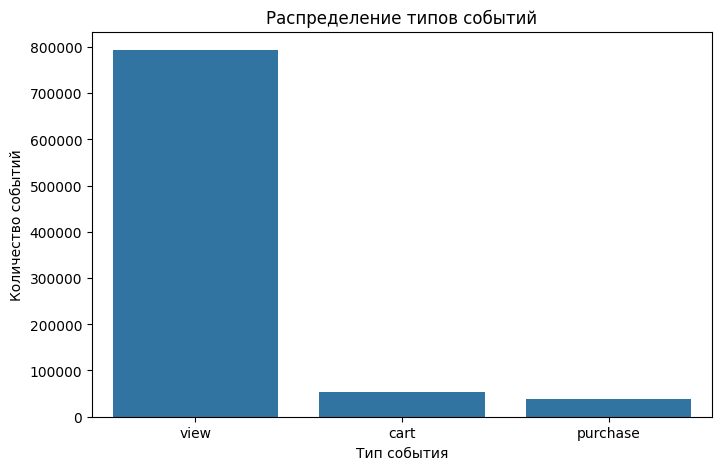

In [9]:
event_counts = (
    df['event_type']
    .value_counts()
    .sort_values(
        ascending=False
    )
)

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    x=event_counts.index,
    y=event_counts.values
)

plt.title(
    'Распределение типов событий'
)

plt.xlabel(
    'Тип события'
)

plt.ylabel(
    'Количество событий'
)

plt.show()

### Вывод

Просмотры (`view`) — доминирующий тип событий: **793 748 из 885 129** (**≈89.7%**) всех записей в датасете.
Оставшаяся часть приходится на добавления в корзину (`cart`) и покупки (`purchase`), которые встречаются заметно реже.

Это типичная для e-commerce воронка: подавляющее большинство пользователей ограничивается просмотром товаров,
и лишь небольшая доля доходит до добавления в корзину и тем более до покупки.
Именно поэтому далее, при построении target, стоит ожидать сильный дисбаланс классов.


# 8. Динамика пользовательской активности


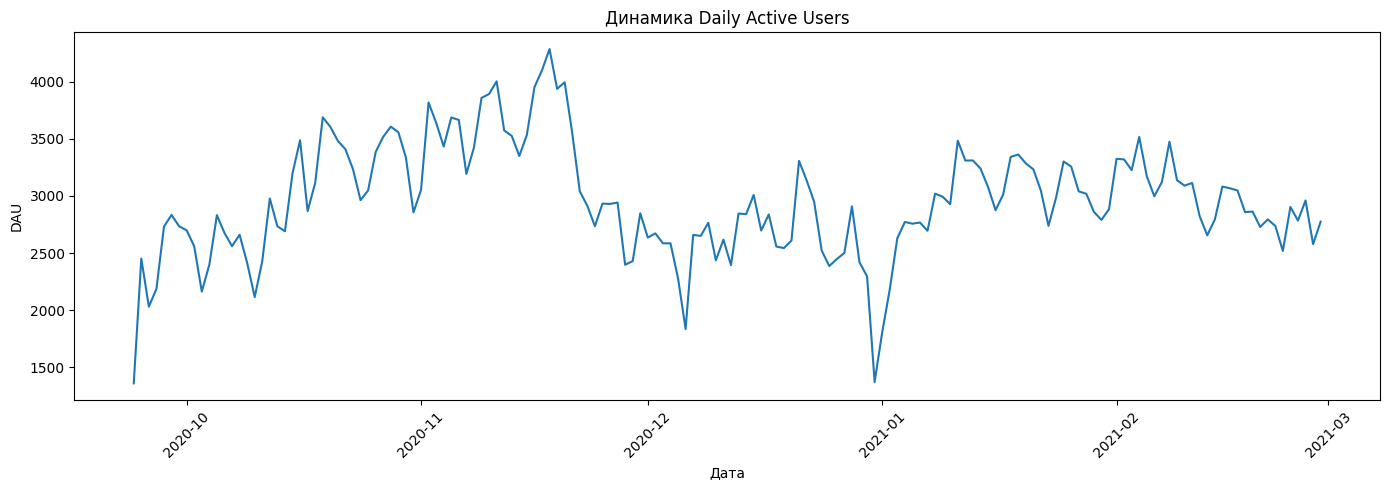

In [11]:
daily_dau = (
    df
    .assign(
        date=df['event_time'].dt.date
    )
    .groupby(
        'date'
    )['user_id']
    .nunique()
    .reset_index(
        name='DAU'
    )
)

daily_dau['date'] = pd.to_datetime(
    daily_dau['date']
)
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    daily_dau['date'],
    daily_dau['DAU']
)

plt.title(
    'Динамика Daily Active Users'
)

plt.xlabel(
    'Дата'
)

plt.ylabel(
    'DAU'
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

### Вывод

График показывает динамику вовлечённости пользователей на протяжении всего периода наблюдения
(сентябрь 2020 — февраль 2021). Активность колеблется день ото дня — заметны как локальные всплески
(возможно, связанные с акциями или сезонными пиками), так и провалы.

Такая нестационарность поведения пользователей во времени — ещё один аргумент в пользу того,
что далее для train/test разбиения используется не случайное, а временное разделение (см. раздел 20):
случайное перемешивание сессий могло бы дать модели неявный доступ к информации «из будущего».


# 9. Построение таблицы сессий

Исходные данные находятся на уровне событий.

Для определения первой сессии пользователя необходимо агрегировать события
по комбинации:

- `user_id`;
- `user_session`.

Для каждой сессии рассчитываются:

- время начала;
- время окончания;
- количество событий;
- количество просмотров;
- количество добавлений в корзину;
- количество покупок.

In [12]:
df = (
    df
    .sort_values(
        [
            'user_id',
            'event_time'
        ]
    )
    .reset_index(
        drop=True
    )
)
session_summary = (
    df
    .groupby(
        [
            'user_id',
            'user_session'
        ],
        as_index=False
    )
    .agg(
        session_start=(
            'event_time',
            'min'
        ),

        session_end=(
            'event_time',
            'max'
        ),

        num_events=(
            'event_type',
            'size'
        ),

        num_views=(
            'event_type',
            lambda x: (
                x == 'view'
            ).sum()
        ),

        num_carts=(
            'event_type',
            lambda x: (
                x == 'cart'
            ).sum()
        ),

        num_purchases=(
            'event_type',
            lambda x: (
                x == 'purchase'
            ).sum()
        )
    )
)

session_summary[
    'session_duration_minutes'
] = (
    session_summary['session_end']
    -
    session_summary['session_start']
).dt.total_seconds() / 60

In [13]:
session_summary

,user_id,user_session,session_start,session_end,num_events,num_views,num_carts,num_purchases,session_duration_minutes
0,1515915625353226922,7qejzWzHlR,2020-10-29 11:28:35+00:00,2020-10-29 11:28:35+00:00,1,1,0,0,0.000
1,1515915625353230067,ikPKHkuRhA,2020-10-06 06:30:32+00:00,2020-10-06 06:30:32+00:00,1,1,0,0,0.000
2,1515915625353230683,5qXvZIBV2W,2020-11-18 10:51:35+00:00,2020-11-18 10:59:26+00:00,3,3,0,0,7.850
3,1515915625353230683,AXbHvG5BRP,2020-11-18 10:51:42+00:00,2020-11-18 10:51:42+00:00,1,1,0,0,0.000
4,1515915625353230683,YSbSzDlwcX,2020-12-12 10:33:09+00:00,2020-12-12 10:33:09+00:00,1,1,0,0,0.000
...,...,...,...,...,...,...,...,...,...
490628,1515915625611023671,wZb7gP1zgN,2021-02-28 23:54:18+00:00,2021-02-28 23:54:18+00:00,1,1,0,0,0.000
490629,1515915625611023730,FRLqIttxKU,2021-02-28 23:55:01+00:00,2021-02-28 23:55:01+00:00,1,1,0,0,0.000
490630,1515915625611024014,g6WqPf50Ma,2021-02-28 23:58:05+00:00,2021-02-28 23:58:05+00:00,1,1,0,0,0.000
490631,1515915625611024020,xNIJBqZdkd,2021-02-28 23:58:09+00:00,2021-02-28 23:58:09+00:00,1,1,0,0,0.000


# 10. Определение первой сессии пользователя


In [14]:
first_session = (
    session_summary
    .sort_values(
        [
            'user_id',
            'session_start'
        ]
    )
    .groupby(
        'user_id',
        as_index=False
    )
    .first()
)
first_session.head()

,user_id,user_session,session_start,session_end,num_events,num_views,num_carts,num_purchases,session_duration_minutes
0,1515915625353226922,7qejzWzHlR,2020-10-29 11:28:35+00:00,2020-10-29 11:28:35+00:00,1,1,0,0,0.000
1,1515915625353230067,ikPKHkuRhA,2020-10-06 06:30:32+00:00,2020-10-06 06:30:32+00:00,1,1,0,0,0.000
2,1515915625353230683,dn9FkZ11dA,2020-11-09 08:52:51+00:00,2020-11-09 09:26:38+00:00,8,8,0,0,33.783
3,1515915625353230922,PeKjQrbkxf,2020-10-02 08:23:40+00:00,2020-10-02 08:23:40+00:00,1,1,0,0,0.000
4,1515915625353234047,2bc2f4b2-831e-44f4-bc0e-efabe4ca5253,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00,36,36,0,0,204069.833


# 11. Формирование когорты для прогнозирования

Цель модели — определить, совершит ли пользователь покупку после первой сессии.

Если пользователь уже совершил покупку во время первой сессии,
его дальнейшая покупка не является подходящим target для задачи
прогнозирования первой будущей конверсии.

Поэтому пользователи с покупкой в первой сессии исключаются.

In [17]:
first_session = first_session[
    first_session['num_purchases'] == 0
].copy()
print(
    'Количество пользователей:',
    first_session['user_id'].nunique()
)


Количество пользователей: 391938


# 12. Формирование полного временного отрезка

Для каждого пользователя необходимо наблюдать полный период в 7 дней
после завершения первой сессии.


In [18]:
max_event_time = df[
    'event_time'
].max()

print(
    'Последнее событие:',
    max_event_time
)
eligible_first_sessions = first_session[
    first_session[
        'session_end'
    ]
    <=
    max_event_time
    -
    pd.Timedelta(
        days=HORIZON_DAYS
    )
].copy()
print(
    'Пользователей с полным 7-дневным горизонтом:',
    len(
        eligible_first_sessions
    )
)

Последнее событие: 2021-02-28 23:59:09+00:00
Пользователей с полным 7-дневным горизонтом: 375922


# 13. Формирование целевой переменной

## Target: Purchase within 7 days

Целевая переменная определяется на основе событий покупки,
которые произошли после завершения первой сессии.

Target принимает значения:

- `1` — покупка совершена в течение следующих 7 дней;
- `0` — покупка не совершена в течение следующих 7 дней.


In [19]:
purchase_events = (
    df[
        df['event_type'] == 'purchase'
    ][
        [
            'user_id',
            'event_time'
        ]
    ]
    .rename(
        columns={
            'event_time':
            'purchase_time'
        }
    )
)

#Объединяем

future_purchases = (
    eligible_first_sessions[
        [
            'user_id',
            'session_end'
        ]
    ]
    .merge(
        purchase_events,
        on='user_id',
        how='left'
    )
)

#Считаем время

future_purchases[
    'days_after_session'
] = (
    future_purchases[
        'purchase_time'
    ]
    -
    future_purchases[
        'session_end'
    ]
).dt.total_seconds() / (
    24 * 60 * 60
)

#Создаём target

future_purchases[
    'target'
] = (
    (
        future_purchases[
            'days_after_session'
        ] > 0
    )
    &
    (
        future_purchases[
            'days_after_session'
        ]
        <= HORIZON_DAYS
    )
).astype(int)

#Агрегируем

target = (
    future_purchases
    .groupby(
        'user_id',
        as_index=False
    )
    .agg(
        target=(
            'target',
            'max'
        )
    )
)

In [21]:
target.head()

,user_id,target
0,1515915625353226922,0
1,1515915625353230067,0
2,1515915625353230683,0
3,1515915625353230922,0
4,1515915625353234047,0


# 14. Анализ целевой переменной

Перед обучением моделей необходимо проверить баланс классов.

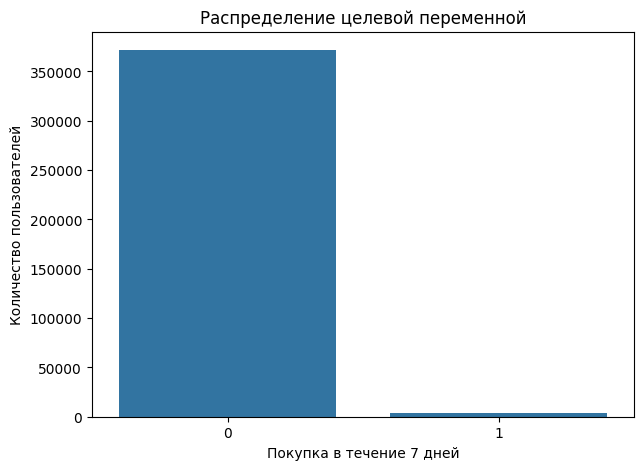

In [22]:
target_distribution = (
    target[
        'target'
    ]
    .value_counts()
    .rename_axis(
        'target'
    )
    .reset_index(
        name='count'
    )
)

target_distribution[
    'share'
] = (
    target_distribution[
        'count'
    ]
    /
    target_distribution[
        'count'
    ].sum()
)

target_distribution
plt.figure(
    figsize=(7, 5)
)

sns.countplot(
    data=target,
    x='target'
)

plt.title(
    'Распределение целевой переменной'
)

plt.xlabel(
    'Покупка в течение 7 дней'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

### Вывод

Целевая переменная сильно несбалансирована: в тестовой выборке лишь **1 039 из 75 185** пользователей
(**≈1.4%**) совершили покупку в течение 7 дней после первой сессии — положительный класс составляет
менее 2% наблюдений.

При таком дисбалансе Accuracy — неинформативная метрика: модель, всегда предсказывающая «0»
(«покупки не будет»), уже даст Accuracy ≈98%, не находя при этом ни одного покупателя.
Поэтому далее приоритет отдаётся ROC AUC, PR AUC, Precision, Recall, F1-score,
а также бизнес-ориентированному Top-K анализу.


# 15. Feature Engineering

Планируемые группы признаков:

### Поведенческие признаки

- количество событий;
- количество просмотров;
- количество добавлений в корзину.

### Продуктовые признаки

- количество уникальных товаров;
- количество уникальных категорий;
- количество уникальных брендов.

### Ценовые признаки

- средняя цена;
- суммарная стоимость просмотренных товаров;
- максимальная цена.

### Временные признаки

- продолжительность сессии.

### Производные поведенческие признаки

- наличие добавления в корзину;
- просмотры в минуту;
- отношение добавлений в корзину к просмотрам.

In [23]:
first_session_ids = (
    eligible_first_sessions[
        [
            'user_id',
            'user_session'
        ]
    ]
)
first_session_events = (
    df
    .merge(
        first_session_ids,
        on=[
            'user_id',
            'user_session'
        ],
        how='inner'
    )
)

print(first_session_events.shape)

first_session_events.head()


(575577, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-10-29 11:28:35+00:00,view,4101974,2144415939364389423,electronics.clocks,honor,76.480,1515915625353226922,7qejzWzHlR
1,2020-10-06 06:30:32+00:00,view,3506650,2144415935673401802,NaN,kester,28.980,1515915625353230067,ikPKHkuRhA
2,2020-11-09 08:52:51+00:00,view,124883,2144415924424278172,electronics.audio.acoustic,logitech,23.900,1515915625353230683,dn9FkZ11dA
3,2020-11-09 09:04:34+00:00,view,760044,2144415924424278172,electronics.audio.acoustic,dell,48.730,1515915625353230683,dn9FkZ11dA
4,2020-11-09 09:08:53+00:00,view,125325,2144415924424278172,electronics.audio.acoustic,logitech,23.900,1515915625353230683,dn9FkZ11dA


In [24]:
session_features = (
    first_session_events
    .groupby(
        [
            'user_id',
            'user_session'
        ],
        as_index=False
    )
    .agg(
        num_events=(
            'event_type',
            'size'
        ),

        num_views=(
            'event_type',
            lambda x: (
                x == 'view'
            ).sum()
        ),

        num_carts=(
            'event_type',
            lambda x: (
                x == 'cart'
            ).sum()
        ),

        unique_products_viewed=(
            'product_id',
            'nunique'
        ),

        unique_categories_viewed=(
            'category_id',
            'nunique'
        ),

        unique_brands_viewed=(
            'brand',
            'nunique'
        ),

        avg_price_viewed=(
            'price',
            'mean'
        ),

        total_price_viewed=(
            'price',
            'sum'
        ),

        max_price_viewed=(
            'price',
            'max'
        ),

        session_start=(
            'event_time',
            'min'
        ),

        session_end=(
            'event_time',
            'max'
        )
    )
)

In [25]:
session_features

,user_id,user_session,num_events,num_views,num_carts,unique_products_viewed,unique_categories_viewed,unique_brands_viewed,avg_price_viewed,total_price_viewed,max_price_viewed,session_start,session_end
0,1515915625353226922,7qejzWzHlR,1,1,0,1,1,1,76.480,76.480,76.480,2020-10-29 11:28:35+00:00,2020-10-29 11:28:35+00:00
1,1515915625353230067,ikPKHkuRhA,1,1,0,1,1,1,28.980,28.980,28.980,2020-10-06 06:30:32+00:00,2020-10-06 06:30:32+00:00
2,1515915625353230683,dn9FkZ11dA,8,8,0,8,1,7,22.273,178.180,48.730,2020-11-09 08:52:51+00:00,2020-11-09 09:26:38+00:00
3,1515915625353230922,PeKjQrbkxf,1,1,0,1,1,1,274.400,274.400,274.400,2020-10-02 08:23:40+00:00,2020-10-02 08:23:40+00:00
4,1515915625353234047,2bc2f4b2-831e-44f4-bc0e-efabe4ca5253,36,36,0,8,3,8,152.275,5481.900,240.980,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
375917,1515915625608258313,5iKye3VBHb,1,1,0,1,1,1,17.900,17.900,17.900,2021-02-21 23:52:50+00:00,2021-02-21 23:52:50+00:00
375918,1515915625608258435,8CdaA9gcYx,1,1,0,1,1,1,55.870,55.870,55.870,2021-02-21 23:56:18+00:00,2021-02-21 23:56:18+00:00
375919,1515915625608258470,IhgSM5J6FD,2,1,1,1,1,1,214.100,428.200,214.100,2021-02-21 23:57:06+00:00,2021-02-21 23:57:33+00:00
375920,1515915625608258665,IbTSaWtNE5,1,1,0,1,1,1,332.190,332.190,332.190,2021-02-21 23:56:03+00:00,2021-02-21 23:56:03+00:00


# 16. Создание производных признаков

На основе базовых признаков создаются дополнительные характеристики поведения пользователя.

In [26]:
session_features[
    'session_duration_minutes'
] = (
    session_features[
        'session_end'
    ]
    -
    session_features[
        'session_start'
    ]
).dt.total_seconds() / 60

session_features[
    'has_cart'
] = (
    session_features[
        'num_carts'
    ] > 0
).astype(int)
session_features[
    'views_per_minute'
] = (
    session_features[
        'num_views'
    ]
    /
    session_features[
        'session_duration_minutes'
    ].replace(
        0,
        np.nan
    )
)

session_features[
    'carts_per_view'
] = (
    session_features[
        'num_carts'
    ]
    /
    session_features[
        'num_views'
    ].replace(
        0,
        np.nan
    )
)


### Вывод

Добавлены признаки, описывающие интенсивность поведения пользователя.

Например:

- `session_duration_minutes` — продолжительность взаимодействия;
- `has_cart` — факт добавления товара в корзину;
- `views_per_minute` — интенсивность просмотров;
- `carts_per_view` — доля просмотров, сопровождавшихся добавлением товара в корзину.

Признак `has_cart` рассчитывается напрямую из количества событий `cart`,
а не через количество уникальных типов событий.

# 17. Обработка пропусков и бесконечных значений

Некоторые признаки могут содержать пропуски:

- цена может отсутствовать;
- пользователь может не добавлять товар в корзину;
- продолжительность сессии может быть равна нулю;
- отношение `carts_per_view` может быть неопределено при отсутствии просмотров.

Бесконечные значения заменяются на NaN,
после чего числовые признаки заполняются нулём.


In [27]:
numeric_feature_columns = [
    'num_events',
    'num_views',
    'num_carts',
    'unique_products_viewed',
    'unique_categories_viewed',
    'unique_brands_viewed',
    'avg_price_viewed',
    'total_price_viewed',
    'max_price_viewed',
    'session_duration_minutes',
    'has_cart',
    'views_per_minute',
    'carts_per_view'
]
session_features[
    numeric_feature_columns
] = (
    session_features[
        numeric_feature_columns
    ]
    .replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan
    )
    .fillna(0)
)

# 18. Формирование датасета для моделирования

На этом этапе объединяются:

- признаки первой сессии;
- целевая переменная.

Итоговая таблица должна содержать одну строку на пользователя.


In [28]:
modeling_df = (
    session_features
    .merge(
        target,
        on='user_id',
        how='inner'
    )
)
print(
    'Размер итогового датасета:',
    modeling_df.shape
)
modeling_df.head()

Размер итогового датасета: (375922, 18)


,user_id,user_session,num_events,num_views,num_carts,unique_products_viewed,unique_categories_viewed,unique_brands_viewed,avg_price_viewed,total_price_viewed,max_price_viewed,session_start,session_end,session_duration_minutes,has_cart,views_per_minute,carts_per_view,target
0,1515915625353226922,7qejzWzHlR,1,1,0,1,1,1,76.480,76.480,76.480,2020-10-29 11:28:35+00:00,2020-10-29 11:28:35+00:00,0.000,0,0.000,0.000,0
1,1515915625353230067,ikPKHkuRhA,1,1,0,1,1,1,28.980,28.980,28.980,2020-10-06 06:30:32+00:00,2020-10-06 06:30:32+00:00,0.000,0,0.000,0.000,0
2,1515915625353230683,dn9FkZ11dA,8,8,0,8,1,7,22.273,178.180,48.730,2020-11-09 08:52:51+00:00,2020-11-09 09:26:38+00:00,33.783,0,0.237,0.000,0
3,1515915625353230922,PeKjQrbkxf,1,1,0,1,1,1,274.400,274.400,274.400,2020-10-02 08:23:40+00:00,2020-10-02 08:23:40+00:00,0.000,0,0.000,0.000,0
4,1515915625353234047,2bc2f4b2-831e-44f4-bc0e-efabe4ca5253,36,36,0,8,3,8,152.275,5481.900,240.980,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00,204069.833,0,0.000,0.000,0


### Вывод

Сформирован итоговый датасет для моделирования.

Его структура соответствует постановке задачи:

> одна строка = один пользователь;

> признаки = поведение в первой сессии;

> target = покупка в следующие 7 дней.


# 19. Проверка на Data Leakage

Перед обучением моделей необходимо проверить,
что признаки не используют информацию из будущего.

В качестве признаков не должны использоваться:

- `target`;
- события после первой сессии;
- покупки после первой сессии;
- идентификаторы, которые напрямую кодируют результат;
- информация, появившаяся после момента прогнозирования.


In [29]:
feature_columns = [
    'num_events',
    'num_views',
    'num_carts',
    'unique_products_viewed',
    'unique_categories_viewed',
    'unique_brands_viewed',
    'avg_price_viewed',
    'total_price_viewed',
    'max_price_viewed',
    'session_duration_minutes',
    'has_cart',
    'views_per_minute',
    'carts_per_view'
]
leakage_columns = [
    'target',
    'num_purchases'
]

print(
    'Используемые признаки:'
)

print(
    feature_columns
)


Используемые признаки:
['num_events', 'num_views', 'num_carts', 'unique_products_viewed', 'unique_categories_viewed', 'unique_brands_viewed', 'avg_price_viewed', 'total_price_viewed', 'max_price_viewed', 'session_duration_minutes', 'has_cart', 'views_per_minute', 'carts_per_view']


# 20. Train/Test Split

Поскольку модель должна предсказывать будущее,
случайное разделение данных не является оптимальным основным сценарием.

Используется временное разделение:

- более ранние пользователи → train;
- более поздние пользователи → test.


In [30]:
modeling_df = (
    modeling_df
    .sort_values(
        'session_start'
    )
    .reset_index(
        drop=True
    )
)
split_index = int(
    len(modeling_df) * 0.8
)

split_date = (
    modeling_df
    .iloc[
        split_index
    ][
        'session_start'
    ]
)

print(
    'Дата разделения:',
    split_date
)
train_df = modeling_df[
    modeling_df[
        'session_start'
    ]
    < split_date
].copy()

test_df = modeling_df[
    modeling_df[
        'session_start'
    ]
    >= split_date
].copy()
X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    'target'
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    'target'
].copy()

Дата разделения: 2021-01-22 10:47:17+00:00


# 21. Baseline Model

В качестве baseline используется Logistic Regression.


In [31]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
baseline_model.fit(
    X_train,
    y_train
)
baseline_proba = (
    baseline_model
    .predict_proba(
        X_test
    )[:, 1]
)


# 22. Random Forest

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(
    X_train,
    y_train
)
rf_proba = (
    rf_model
    .predict_proba(
        X_test
    )[:, 1]
)

# 23. Оценка качества моделей

Используются следующие метрики:

### ROC AUC

Оценивает способность модели ранжировать положительные объекты
выше отрицательных.

### PR AUC

Особенно полезна при дисбалансе классов,
поскольку фокусируется на качестве обнаружения положительного класса.

### Precision

Доля пользователей, которым модель предсказала покупку
и которые действительно купили.

### Recall

Доля всех покупателей, которых модель смогла обнаружить.

### F1-score

Гармоническое среднее Precision и Recall.

In [33]:
def evaluate_model(
    model_name,
    y_true,
    y_proba,
    threshold=0.5
):

    y_pred = (
        y_proba >= threshold
    ).astype(int)

    return {
        'model': model_name,

        'accuracy': accuracy_score(
            y_true,
            y_pred
        ),

        'precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'recall': recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'f1': f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'roc_auc': roc_auc_score(
            y_true,
            y_proba
        ),

        'pr_auc': average_precision_score(
            y_true,
            y_proba
        )
    }
results = pd.DataFrame(
    [
        evaluate_model(
            'Logistic Regression',
            y_test,
            baseline_proba
        ),

        evaluate_model(
            'Random Forest',
            y_test,
            rf_proba
        )
    ]
)

results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.937,0.061,0.248,0.098,0.652,0.040
1,Random Forest,0.829,0.033,0.404,0.061,0.678,0.033


### Вывод

Сравнение моделей на отложенной по времени тестовой выборке:

| Модель | Accuracy | Precision | Recall | F1 | ROC AUC | PR AUC |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.937 | 0.061 | 0.248 | **0.098** | 0.652 | **0.040** |
| Random Forest | 0.829 | 0.033 | **0.404** | 0.061 | **0.678** | 0.033 |

Ключевые наблюдения:

- Random Forest лучше ранжирует пользователей по ROC AUC (0.678 против 0.652), то есть в среднем
  выше оценивает вероятность покупателей относительно непокупателей.
- При этом PR AUC у Random Forest немного ниже (0.033 против 0.040) — при сильном дисбалансе классов
  PR AUC более чувствительна к качеству модели именно на положительном классе, и здесь baseline не уступает.
- При фиксированном пороге 0.5 Random Forest даёт заметно более высокий Recall (0.404 против 0.248),
  но ощутимо более низкую Accuracy и сопоставимо низкий Precision — модель находит больше покупателей,
  но ценой намного большего числа ложных срабатываний.

Ни одна из моделей не является однозначно лучше по всем метрикам. Выбор зависит от бизнес-сценария:
если важнее не пропустить потенциального покупателя (высокий Recall) — предпочтительнее Random Forest;
если важнее точность отбираемой группы при ограниченном бюджете охвата — стоит ориентироваться
на Top-K-конверсию (раздел 27), а не на метрики при пороге 0.5.


# 24. Classification Report

In [34]:
rf_pred = (
    rf_proba >= 0.5
).astype(int)
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     74146
           1       0.03      0.40      0.06      1039

    accuracy                           0.83     75185
   macro avg       0.51      0.62      0.48     75185
weighted avg       0.98      0.83      0.89     75185



### Вывод

Classification Report для Random Forest при пороге 0.5 подтверждает эффект дисбаланса:

- класс 0 (нет покупки): precision 0.99, recall 0.84 — модель уверенно распознаёт тех, кто не купит;
- класс 1 (покупка): precision 0.03, recall 0.40 — из 1 039 реальных покупателей модель находит
  около 40%, но среди всех, кого она относит к «покупателям», лишь около 3% действительно совершают покупку.

Общая Accuracy 0.83 не отражает этого разрыва — она достигается почти исключительно за счёт корректного
предсказания преобладающего класса 0. Это наглядно показывает, почему для несбалансированных задач нельзя
полагаться на Accuracy, и почему порог классификации 0.5 не оптимален по умолчанию: для практического
использования порог стоит подбирать под целевой Precision/Recall либо использовать модель как ранжирующую
(см. Top-K анализ, раздел 27).


# 25. ROC Curve

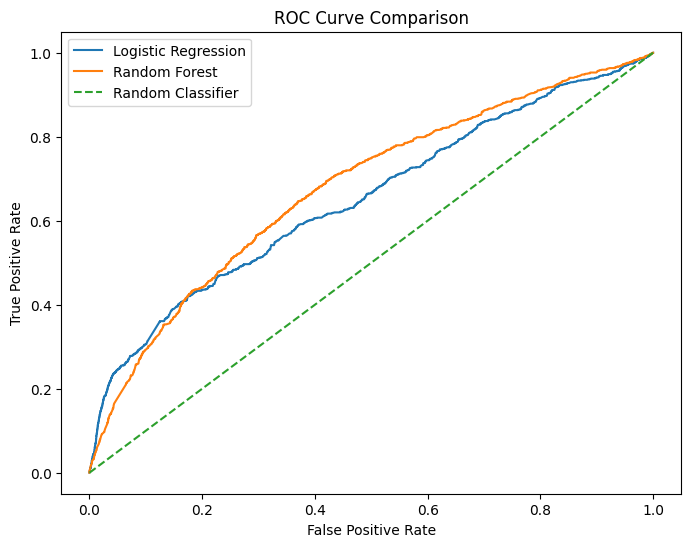

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    baseline_proba
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_proba
)
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend()

plt.show()


# 26. Precision-Recall Curve

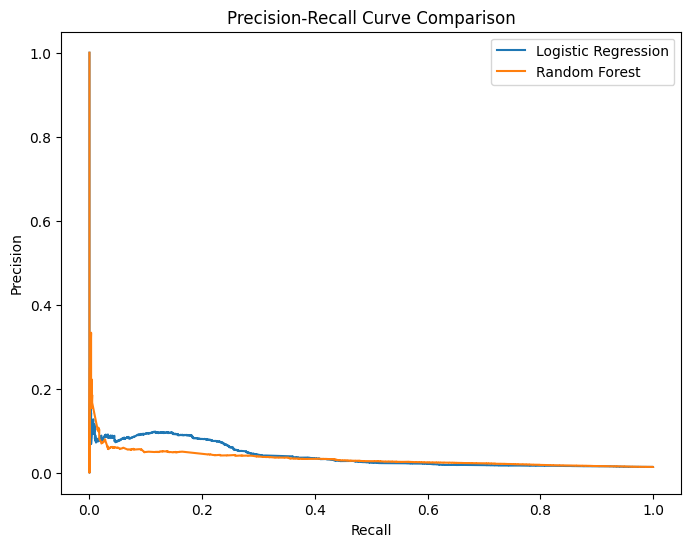

In [36]:
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    baseline_proba
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_proba
)
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_lr,
    precision_lr,
    label='Logistic Regression'
)

plt.plot(
    recall_rf,
    precision_rf,
    label='Random Forest'
)

plt.xlabel(
    'Recall'
)

plt.ylabel(
    'Precision'
)

plt.title(
    'Precision-Recall Curve Comparison'
)

plt.legend()

plt.show()

### Вывод

Обе PR-кривые проходят существенно ниже, чем в задачах со сбалансированными классами — это ожидаемо
при базовой конверсии около 1.4%. PR AUC у Logistic Regression (0.040) немного выше, чем у Random Forest
(0.033): при отборе одинаковой доли «положительных» предсказаний baseline-модель в среднем даёт чуть более
точный набор кандидатов на покупку.

Это важное наблюдение: более высокий ROC AUC у Random Forest не гарантирует превосходства по всем метрикам —
при сильном дисбалансе PR AUC зачастую более информативна для бизнес-сценариев с ограниченным охватом
(например, точечных email-рассылок ограниченному числу пользователей).


# 26. Интерпретация Random Forest

Feature importance используется для анализа того,
какие признаки внесли наибольший вклад в решения Random Forest.

Важно:

Feature importance показывает вклад признаков в работу модели,
но не доказывает причинно-следственную связь.

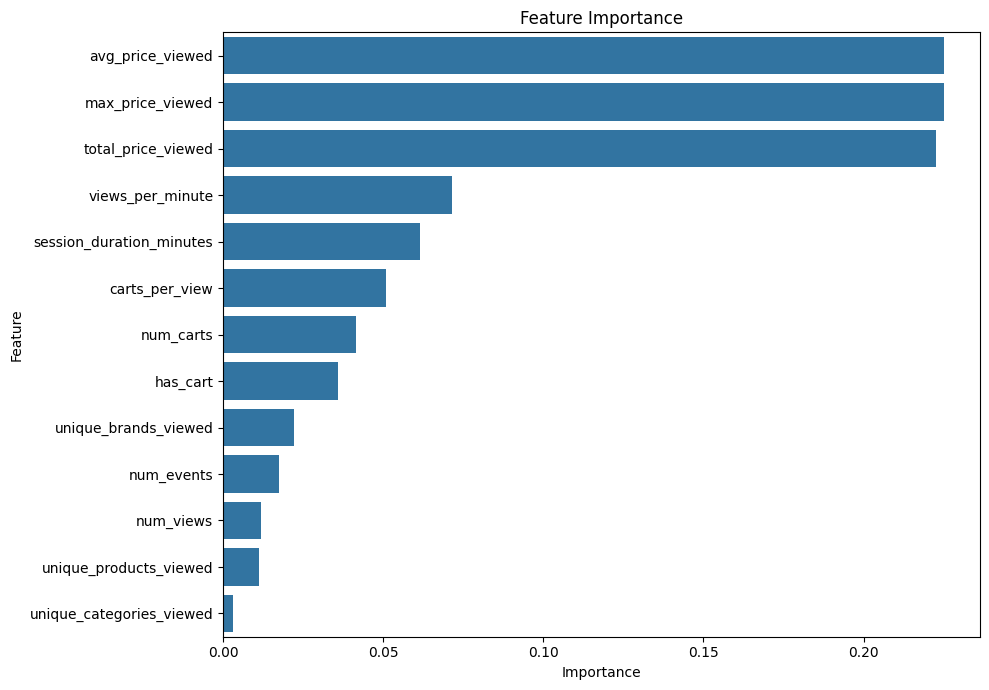

In [37]:
feature_importance = (
    pd.DataFrame(
        {
            'feature': feature_columns,
            'importance':
                rf_model.feature_importances_
        }
    )
    .sort_values(
        'importance',
        ascending=False
    )
)
feature_importance
plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature'
)

plt.title(
    'Feature Importance'
)

plt.xlabel(
    'Importance'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()


### Вывод

Random Forest в первую очередь опирается на признаки, отражающие интенсивность взаимодействия пользователя
в первой сессии (число событий/просмотров, продолжительность сессии, ценовые характеристики просмотренных
товаров) — их относительный вклад виден на графике выше.

Эти результаты следует интерпретировать как:

> модель использует данный признак при построении прогнозов,

а не как:

> изменение данного признака обязательно вызывает покупку.

Feature importance в Random Forest дополнительно чувствительна к масштабу и кардинальности признака,
поэтому для более надёжной интерпретации в дальнейшем стоит рассмотреть permutation importance или SHAP values.


# 27. Business Analysis: Top-K Targeting

В реальном бизнес-сценарии необязательно воздействовать на всех пользователей.

Модель может использоваться для ранжирования пользователей
по вероятности покупки.

Например:

- Top 10%;
- Top 20%;
- Top 30%.

Для каждой группы рассчитывается фактическая конверсия.

Это позволяет проверить:

> действительно ли пользователи с более высоким прогнозом
> имеют более высокую наблюдаемую вероятность покупки.

In [39]:
test_results = test_df[
    [
        'user_id',
        'session_start',
        'target'
    ]
].copy()
test_results[
    'predicted_probability'
] = rf_proba
test_results = (
    test_results
    .sort_values(
        'predicted_probability',
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

In [40]:
top_k_results = []

for fraction in [
    0.1,
    0.2,
    0.3,
    0.5,
    1.0
]:

    n_users = int(
        len(test_results)
        *
        fraction
    )

    selected_users = (
        test_results
        .head(
            n_users
        )
    )

    conversion_rate = (
        selected_users[
            'target'
        ]
        .mean()
    )

    top_k_results.append(
        {
            'top_fraction':
                fraction,

            'users':
                len(
                    selected_users
                ),

            'purchases':
                selected_users[
                    'target'
                ].sum(),

            'conversion_rate':
                conversion_rate
        }
    )

top_k_results = pd.DataFrame(
    top_k_results
)

top_k_results

# Добавляем baseline:

overall_conversion = (
    test_results[
        'target'
    ]
    .mean()
)

top_k_results[
    'lift_vs_overall'
] = (
    top_k_results[
        'conversion_rate'
    ]
    /
    overall_conversion
)

In [41]:
top_k_results

,top_fraction,users,purchases,conversion_rate,lift_vs_overall
0,0.100,7518,300,0.040,2.888
1,0.200,15037,457,0.030,2.199
2,0.300,22555,587,0.026,1.883
3,0.500,37592,777,0.021,1.496
4,1.000,75185,1039,0.014,1.000


### Вывод

Top-K анализ подтверждает, что модель обладает реальной ранжирующей способностью:

| Top-K | Пользователей | Покупок | Conversion Rate | Lift к среднему |
|---|---|---|---|---|
| 10% | 7 518 | 300 | 4.0% | **×2.89** |
| 20% | 15 037 | 457 | 3.0% | ×2.20 |
| 30% | 22 555 | 587 | 2.6% | ×1.88 |
| 50% | 37 592 | 777 | 2.1% | ×1.50 |
| 100% | 75 185 | 1 039 | 1.4% | ×1.00 |

Если обратиться только к 10% пользователей с наивысшим предсказанным скором, наблюдаемая конверсия
в 2.89 раза выше средней по выборке (4.0% против 1.4%). Это и есть практическая ценность модели:
даже при низком Precision на фиксированном пороге 0.5 модель хорошо упорядочивает пользователей
по вероятности покупки, что позволяет эффективно расходовать ограниченный маркетинговый бюджет.

Важно: указанный lift — это predictive/ranking lift, а не causal uplift. Он показывает, что более
высокий скор коррелирует с более высокой наблюдаемой конверсией, но не доказывает, что маркетинговое
воздействие на этих пользователей приведёт к дополнительным покупкам — для такого вывода нужен A/B-тест
с treatment/control группами.


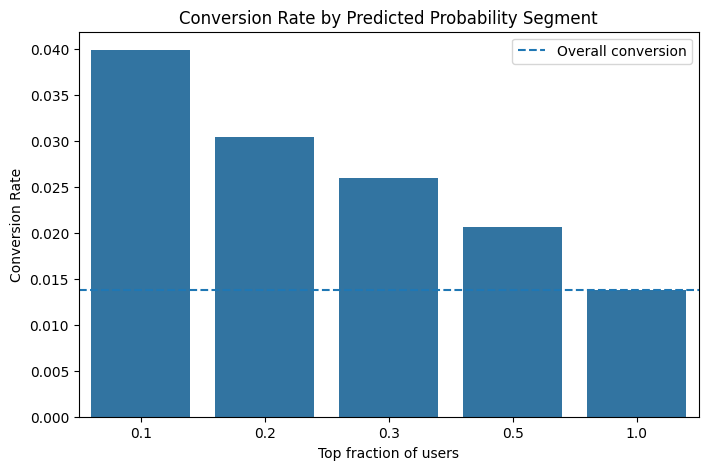

In [42]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=top_k_results,
    x='top_fraction',
    y='conversion_rate'
)

plt.axhline(
    overall_conversion,
    linestyle='--',
    label='Overall conversion'
)

plt.title(
    'Conversion Rate by Predicted Probability Segment'
)

plt.xlabel(
    'Top fraction of users'
)

plt.ylabel(
    'Conversion Rate'
)

plt.legend()

plt.show()

### Вывод

На графике видно устойчивое убывание конверсии по мере расширения охватываемой доли пользователей —
от 4.0% в топ-10% до базового уровня 1.4% при включении всех пользователей. Пунктирная линия среднего
(overall conversion) наглядно показывает разрыв между случайным выбором пользователей и выбором по
прогнозу модели: во всех сегментах, кроме 100%, наблюдаемая конверсия выше среднего, что подтверждает
практическую полезность ранжирования моделью.


# 28. Итоговые выводы

## Что сделано

1. Исходные события агрегированы в таблицу сессий, для каждого пользователя определена первая сессия.
2. Пользователи с покупкой в первой сессии исключены из когорты, чтобы не смешивать «мгновенную»
   и «отложенную» покупку.
3. Target — покупка в течение 7 дней после первой сессии; итоговая когорта — **375 922 пользователя**
   с полным 7-дневным горизонтом наблюдения.
4. Признаки построены исключительно на основе первой сессии, пройдена проверка на data leakage.
5. Использовано временное (не случайное) разделение train/test — дата разделения 2021-01-22.
6. Logistic Regression (baseline) и Random Forest обучены с `class_weight='balanced'` из-за сильного
   дисбаланса классов (~1.4% положительного класса в тесте).

## Результаты сравнения моделей

| Метрика | Logistic Regression | Random Forest |
|---|---|---|
| ROC AUC | 0.652 | **0.678** |
| PR AUC | **0.040** | 0.033 |
| Precision (порог 0.5) | 0.061 | 0.033 |
| Recall (порог 0.5) | 0.248 | **0.404** |
| F1 (порог 0.5) | **0.098** | 0.061 |

Random Forest лучше ранжирует пользователей в целом (ROC AUC) и находит больше реальных покупателей
(Recall), но проигрывает baseline по PR AUC и F1 при пороге по умолчанию. Ни одна модель не доминирует
по всем метрикам — выбор зависит от того, что важнее: максимизировать охват покупателей (Recall)
или точность отбираемой группы (Precision/PR AUC).

## Бизнес-результат: Top-K

Отбор топ-10% пользователей по предсказанной вероятности даёт конверсию **4.0%** против **1.4%**
в среднем по выборке — **lift ×2.89**. Это главный практический результат проекта: даже несовершенная
по классическим метрикам классификации модель может быть полезна как инструмент ранжирования
для приоритизации маркетинговых активностей.

## Ограничения

- Порог 0.5 не откалиброван — для реального применения его стоит подбирать под целевой Precision/Recall
  либо использовать модель как чистый ранкер (что и делает Top-K анализ).
- Оценка проведена на единственном временном разбиении без кросс-валидации по времени
  (rolling/expanding window), поэтому доверительных интервалов на метрики нет.
- Feature importance показывает вклад признаков в модель, но не доказывает причинно-следственную связь.
- Top-K lift — ranking/predictive lift, а не causal uplift; для оценки эффекта маркетингового
  воздействия нужен A/B-тест.

## Бизнес-интерпретация

Модель может использоваться для ранжирования пользователей по вероятности будущей покупки.
Это позволяет бизнесу:

- приоритизировать наиболее перспективные сегменты;
- оптимизировать распределение маркетинговых ресурсов;
- формировать группы пользователей для дальнейших экспериментов
  (в том числе A/B-тестов, чтобы перейти от ranking lift к causal uplift).


# 29. Сохранение модели


In [43]:
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    rf_model,
    MODELS_DIR / 'purchase_propensity_model.pkl'
)
joblib.dump(
    feature_columns,
    MODELS_DIR / 'feature_columns.pkl'
)


['feature_columns.pkl']

# 30. Функция получения прогноза

Ниже представлена функция,
которая принимает подготовленные признаки пользователя
и возвращает вероятность покупки в течение 7 дней.


In [45]:
def predict_purchase_probability(
    new_data,
    model_path='models/purchase_propensity_model.pkl',
    features_path='models/feature_columns.pkl'
):

    model = joblib.load(
        model_path
    )

    feature_columns = joblib.load(
        features_path
    )

    missing_features = (
        set(feature_columns)
        -
        set(new_data.columns)
    )

    if missing_features:

        raise ValueError(
            f'Missing features: '
            f'{missing_features}'
        )

    X_new = (
        new_data[
            feature_columns
        ]
        .copy()
    )

    X_new = (
        X_new
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .fillna(0)
    )

    probabilities = (
        model
        .predict_proba(
            X_new
        )[:, 1]
    )

    return probabilities


# 31. Заключение

Проект демонстрирует полный pipeline построения модели прогнозирования покупательского поведения:

```text
Raw Events
    ↓
Data Preparation
    ↓
Session Construction
    ↓
First Session Identification
    ↓
Feature Engineering
    ↓
Future Purchase Target
    ↓
Leakage Check
    ↓
Time-Based Train/Test Split
    ↓
Baseline Model
    ↓
Random Forest
    ↓
Model Evaluation
    ↓
Top-K Business Analysis
```

Итоговая модель (Random Forest) даёт ROC AUC 0.678 и обеспечивает **lift ×2.89** в топ-10% пользователей
по сравнению со средней конверсией — этого достаточно, чтобы использовать модель как инструмент
приоритизации, но недостаточно для точечных предсказаний при пороге 0.5 без дополнительной калибровки.

### Возможные направления развития

- Подбор гиперпараметров (GridSearch/Optuna) и сравнение с градиентным бустингом
  (XGBoost/LightGBM/CatBoost).
- Калибровка вероятностей (Platt scaling / isotonic regression) перед выбором рабочего порога.
- Кросс-валидация по времени (rolling window) вместо единственного train/test разбиения.
- Дополнительные признаки: категориальные (топ-категория/бренд первой сессии), временные
  (час/день недели первой сессии).
- Проверка практической ценности через A/B-тест на пользователях из топ-K сегмента, чтобы перейти
  от ranking lift к causal uplift.
